In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
T_max = 1000

In [3]:
# Настройка шрифта для всех элементов графика
plt.rcParams.update({
	"font.size": 16,            # размер шрифта
	"font.family": "serif",      # шрифт, можно "Times New Roman", "DejaVu Serif"
	"axes.labelsize": 18,        # размер подписей осей
	"axes.titlesize": 20,        # размер заголовка
	"xtick.labelsize": 14,       # размер подписей делений X
	"ytick.labelsize": 14        # размер подписей делений Y
})

In [4]:
folder = "data/term/"

In [5]:
# --- Загрузка данных ---

folder_path = Path(folder)   # или "."

files = list(folder_path.glob("term_*.dat"))

if not files:
	raise FileNotFoundError("Нет файлов term_*.dat")

filename = str(files[1])

print(files[1].name)
print(files[1].parent)

name_without_extension = files[1].stem[5:]

# filename = "gem_glass64_J0_0.dat"
# input_file = Path(filename)

try:
	# open(input_file, "r")
	# open(folder + filename, "r")
	open(filename, "r")
	print("File opened: \"" + filename + "\"!")
	# input_file = Path(folder + filename)
	input_file = Path(filename)
except IOError:
	print("Error opening file \"" + filename + "\"!")

FileNotFoundError: Нет файлов term_*.dat

gem_glass64_J0_1_H0.0: T_CW = 0.0007


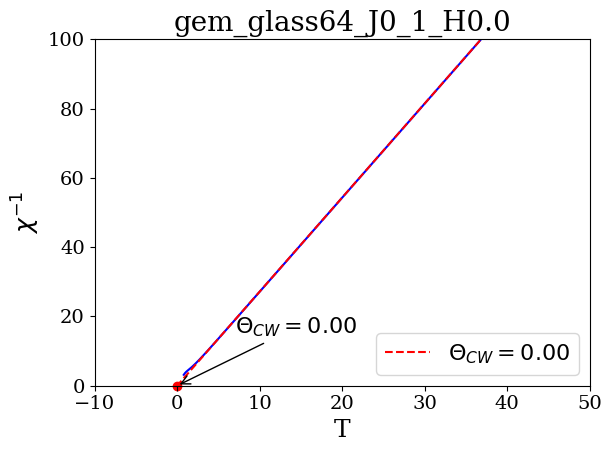

In [ ]:
df = pd.read_csv(input_file, sep=r"\s+", engine="python")

x = df.iloc[:, 0]   # первый столбец — X
y = df.iloc[:, 4]   # пятый столбец

y_safe = np.where(y != 0, 1 / y, np.nan)

mask = (x >= 0.8) & (x <= T_max)

# --- Построение графиков ---

# Первый график: 1/y
plt.plot(x[mask], y_safe[mask], color="blue")


# --- Выбор правой части (например, x > 3.5) для аппроксимации ---
mask2 = x > 500
x_right = x[mask2]
y_right = y_safe[mask2]

# --- Линейная аппроксимация правой части ---
k, b = np.polyfit(x_right, y_right, 1)

# --- Продление прямой ---
# Берем диапазон X немного больше исходного
x_extended = np.linspace(x_right.min() - 1000, x_right.max(), 100)
y_extended = k * x_extended + b


theta = -b / k
print(f"{name_without_extension}: T_CW = {theta:.4f}")

# точка пересечения
plt.scatter(theta, 0, color="red", clip_on=False)
# plt.scatter(theta, 0, color="red", marker="x", s=150, linewidths=2)
# plt.plot(theta, 0, 'rx')  # r = red, x = крестик

plt.annotate(
	r"$\Theta_{CW} = %.2f$" % theta,
	xy=(theta, 0),
	xytext=(theta + 7, 15),
	arrowprops=dict(arrowstyle="->")
)

plt.plot(x_extended, y_extended, label=rf"$\Theta_{{CW}} = {theta:.2f}$", color="red", linestyle="--")

# plt.legend(loc="best")
plt.legend(loc="lower right")

# Настройка графика
plt.xlabel("T")
#plt.ylabel(df.columns[4])
# plt.ylabel(r"1/$\chi$")
plt.ylabel(r"$\chi^{-1}$")
# plt.title("(c)")
plt.title(name_without_extension)


# === ДИАПАЗОНЫ ===
plt.xlim(-10, 50)     # X 
plt.ylim(0, 100)    # Y 

# plt.grid()
# plt.axhline(0)  # ось X
# plt.axvline(0)  # ось Y
plt.tight_layout()
# Сохранение графика в файл
# plt.savefig(f"{folder_path}/theta_{name_without_extension}.png", dpi=300, bbox_inches='tight')  # формат можно изменить: .png, .jpg, .pdf, .svg
plt.show()
plt.close()


In [ ]:
# import theta
# theta.theta(folder, files[0].name, T_max)

data\term\ferro\term_gem_glass64_J100_0_H0.0_G2_f5_M62_E-102.dat
data\term\ferro\term_gem_glass64_J100_3_H0.0_G30_f6_M64_E-100.dat
data\term\ferro\term_gem_glass64_J104_0_H0.0_G6_f4_M64_E-104.dat
data\term\ferro\term_gem_glass64_J104_4_H0.0_G8_f4_M64_E-104.dat
data\term\ferro\term_gem_glass64_J110_0_H0.0_G2_f1_M64_E-110.dat
data\term\ferro\term_gem_glass64_J110_4_H0.0_G4_f1_M64_E-110.dat
data\term\ferro\term_gem_glass64_J112_9_H0.0_G2_f0_M64_E-112.dat
data\term\ferro\term_gem_glass64_J16_9_H0.0_G71288_f19_M24_E-74.dat
data\term\ferro\term_gem_glass64_J26_1_H0.0_G194796_f19_M28_E-74.dat
data\term\ferro\term_gem_glass64_J48_1_H0.0_G20988_f20_M32_E-72.dat
data\term\ferro\term_gem_glass64_J86_1_H0.0_G168_f11_M58_E-90.dat
data\term\ferro\term_gem_glass64_J90_9_H0.0_G264_f10_M60_E-92.dat
data\term\ferro\term_gem_glass64_J96_9_H0.0_G24_f7_M60_E-98.dat


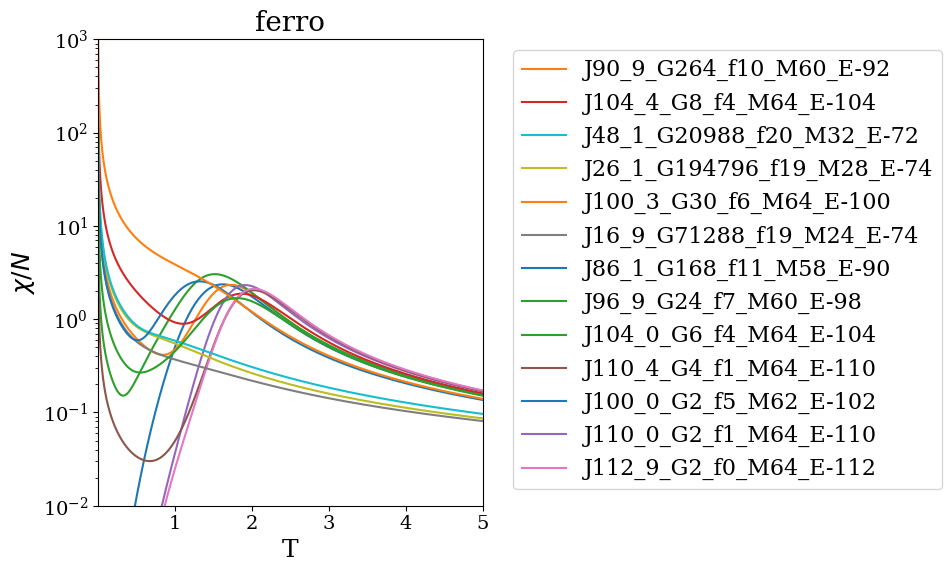

In [44]:
# --- Загрузка данных ---
folder = "data/term/ferro/"
folder_path = Path(folder)   # или "."

files = list(folder_path.glob("term_*.dat"))

if not files:
	raise FileNotFoundError("Нет файлов term_*.dat")

plt.figure(figsize=(10, 6))

# магнитная восприимчивость
# for i in range(1): # files:
for i in files:
	filename = str(i)
	print(filename)
	# filename = str(files[1])

	open(filename, "r")
	input_file = Path(filename)

	# --- имя без расширения ---
	# name_without_extension = input_file.stem[17:]
	name_without_extension = input_file.stem
	# name_without_extension = name_without_extension.strip('term_gem_glass64_').strip('_H0.0')
	name_without_extension = name_without_extension.replace('term_gem_glass64_', '').replace('_H0.0', '')
	# name_without_extension = name_without_extension.strip('_H0.0')
	# name_without_extension = name_without_extension

	# sep=r"\s+" означает "один или несколько пробелов/табов"
	df = pd.read_csv(input_file, sep=r"\s+", engine="python")

	x = df.iloc[:, 0]   # первый столбец — X (температура)
	y = df.iloc[:, 4]   # пятый столбец (восприимчивость)

	# --- Построение графиков ---

	# plt.plot(x, y, color="blue", label="G_gs, N_frustrations")
	# plt.plot(x, y, label="G_gs, N_frustrations")
	plt.plot(x, y, label=name_without_extension)



# Настройка графика
plt.xlabel("T")
#plt.ylabel(df.columns[4])
# plt.ylabel(r"1/$\chi$")
plt.ylabel(r"$\chi/N$")
# plt.title("(c)")
# plt.title(name_without_extension)
plt.title('ferro')

# plt.legend(loc="best")
# Получаем текущие линии и их данные
lines = plt.gca().get_lines()
handles, labels = plt.gca().get_legend_handles_labels()

# Сортируем по первому значению Y
pairs = list(zip(handles, labels))
sorted_pairs = sorted(pairs, key=lambda pair: pair[0].get_ydata()[0], reverse=True)

handles_sorted, labels_sorted = zip(*sorted_pairs)

# Применяем отсортированную легенду
# plt.legend(handles_sorted, labels_sorted)
plt.legend(handles_sorted, labels_sorted, bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.xscale("log")
plt.yscale("log")


# === ДИАПАЗОНЫ ===
plt.xlim(0.001, 5)     # X от 0 до 10
plt.ylim(0.01, 1000)    # Y от -5 до 20

plt.tight_layout()

# Сохранение графика в файл
# plt.savefig(f"{folder_path}/Xi_{name_without_extension}.png", dpi=300, bbox_inches='tight')  # формат можно изменить: .png, .jpg, .pdf, .svg
plt.show()

plt.close()

data\term\ferro\1\term_gem_glass64_J16_9_H0.0_G71288_f19_M24_E-74.dat
data\term\ferro\1\term_gem_glass64_J26_1_H0.0_G194796_f19_M28_E-74.dat
data\term\ferro\1\term_gem_glass64_J48_1_H0.0_G20988_f20_M32_E-72.dat


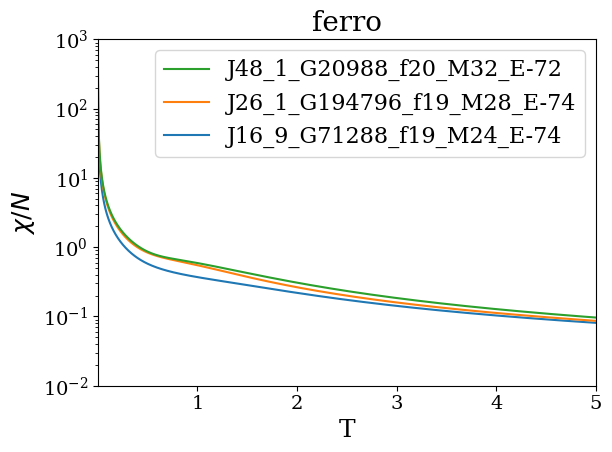

In [43]:
# --- Загрузка данных ---
folder = "data/term/ferro/1/"
folder_path = Path(folder)   # или "."

files = list(folder_path.glob("term_*.dat"))

if not files:
	raise FileNotFoundError("Нет файлов term_*.dat")

# plt.figure(figsize=(10, 6))

# магнитная восприимчивость
# for i in range(1): # files:
for i in files:
	filename = str(i)
	print(filename)
	# filename = str(files[1])

	open(filename, "r")
	input_file = Path(filename)

	# --- имя без расширения ---
	# name_without_extension = input_file.stem[17:]
	name_without_extension = input_file.stem
	# name_without_extension = name_without_extension.strip('term_gem_glass64_').strip('_H0.0')
	name_without_extension = name_without_extension.replace('term_gem_glass64_', '').replace('_H0.0', '')
	# name_without_extension = name_without_extension.strip('_H0.0')
	# name_without_extension = name_without_extension

	# sep=r"\s+" означает "один или несколько пробелов/табов"
	df = pd.read_csv(input_file, sep=r"\s+", engine="python")

	x = df.iloc[:, 0]   # первый столбец — X (температура)
	y = df.iloc[:, 4]   # пятый столбец (восприимчивость)

	# --- Построение графиков ---

	# plt.plot(x, y, color="blue", label="G_gs, N_frustrations")
	# plt.plot(x, y, label="G_gs, N_frustrations")
	plt.plot(x, y, label=name_without_extension)



# Настройка графика
plt.xlabel("T")
#plt.ylabel(df.columns[4])
# plt.ylabel(r"1/$\chi$")
plt.ylabel(r"$\chi/N$")
# plt.title("(c)")
# plt.title(name_without_extension)
plt.title('ferro')

# plt.legend(loc="best")
# Получаем текущие линии и их данные
lines = plt.gca().get_lines()
handles, labels = plt.gca().get_legend_handles_labels()

# Сортируем по первому значению Y
pairs = list(zip(handles, labels))
sorted_pairs = sorted(pairs, key=lambda pair: pair[0].get_ydata()[0], reverse=True)

handles_sorted, labels_sorted = zip(*sorted_pairs)

# Применяем отсортированную легенду
plt.legend(handles_sorted, labels_sorted)

# plt.xscale("log")
plt.yscale("log")


# === ДИАПАЗОНЫ ===
plt.xlim(0.001, 5)     # X от 0 до 10
plt.ylim(0.01, 1000)    # Y от -5 до 20

plt.tight_layout()

# Сохранение графика в файл
# plt.savefig(f"{folder_path}/Xi_{name_without_extension}.png", dpi=300, bbox_inches='tight')  # формат можно изменить: .png, .jpg, .pdf, .svg
plt.show()

plt.close()

data\term\ferro\2\term_gem_glass64_J100_0_H0.0_G2_f5_M62_E-102.dat
data\term\ferro\2\term_gem_glass64_J110_0_H0.0_G2_f1_M64_E-110.dat
data\term\ferro\2\term_gem_glass64_J112_9_H0.0_G2_f0_M64_E-112.dat


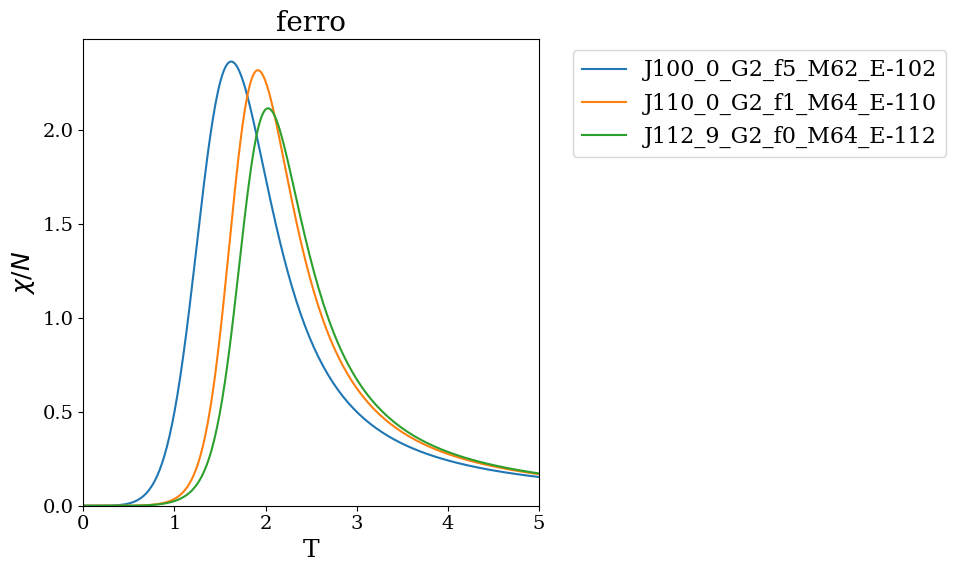

In [42]:
# --- Загрузка данных ---
folder = "data/term/ferro/2/"
folder_path = Path(folder)   # или "."

files = list(folder_path.glob("term_*.dat"))

if not files:
	raise FileNotFoundError("Нет файлов term_*.dat")

plt.figure(figsize=(10, 6))

# магнитная восприимчивость
# for i in range(1): # files:
for i in files:
	filename = str(i)
	print(filename)
	# filename = str(files[1])

	open(filename, "r")
	input_file = Path(filename)

	# --- имя без расширения ---
	# name_without_extension = input_file.stem[17:]
	name_without_extension = input_file.stem
	# name_without_extension = name_without_extension.strip('term_gem_glass64_').strip('_H0.0')
	name_without_extension = name_without_extension.replace('term_gem_glass64_', '').replace('_H0.0', '')
	# name_without_extension = name_without_extension.strip('_H0.0')
	# name_without_extension = name_without_extension

	# sep=r"\s+" означает "один или несколько пробелов/табов"
	df = pd.read_csv(input_file, sep=r"\s+", engine="python")

	x = df.iloc[:, 0]   # первый столбец — X (температура)
	y = df.iloc[:, 4]   # пятый столбец (восприимчивость)

	# --- Построение графиков ---

	# plt.plot(x, y, color="blue", label="G_gs, N_frustrations")
	# plt.plot(x, y, label="G_gs, N_frustrations")
	plt.plot(x, y, label=name_without_extension)



# Настройка графика
plt.xlabel("T")
#plt.ylabel(df.columns[4])
# plt.ylabel(r"1/$\chi$")
plt.ylabel(r"$\chi/N$")
# plt.title("(c)")
# plt.title(name_without_extension)
plt.title('ferro')

# plt.legend(loc="best")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.xscale("log")
# plt.yscale("log")


# === ДИАПАЗОНЫ ===
plt.xlim(0, 5)     # X от 0 до 10
plt.ylim(0.,)    # Y от -5 до 20

plt.tight_layout()

# Сохранение графика в файл
# plt.savefig(f"{folder_path}/Xi_{name_without_extension}.png", dpi=300, bbox_inches='tight')  # формат можно изменить: .png, .jpg, .pdf, .svg
plt.show()

plt.close()

data\term\ferro\3\term_gem_glass64_J100_3_H0.0_G30_f6_M64_E-100.dat
data\term\ferro\3\term_gem_glass64_J104_0_H0.0_G6_f4_M64_E-104.dat
data\term\ferro\3\term_gem_glass64_J104_4_H0.0_G8_f4_M64_E-104.dat
data\term\ferro\3\term_gem_glass64_J110_4_H0.0_G4_f1_M64_E-110.dat
data\term\ferro\3\term_gem_glass64_J86_1_H0.0_G168_f11_M58_E-90.dat
data\term\ferro\3\term_gem_glass64_J90_9_H0.0_G264_f10_M60_E-92.dat
data\term\ferro\3\term_gem_glass64_J96_9_H0.0_G24_f7_M60_E-98.dat


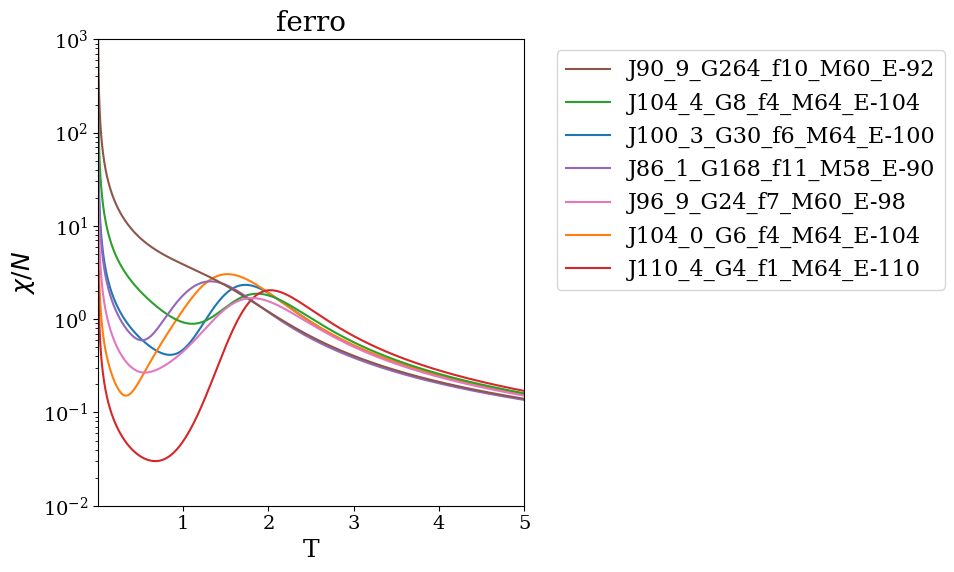

In [39]:
# --- Загрузка данных ---
folder = "data/term/ferro/3/"
folder_path = Path(folder)   # или "."

files = list(folder_path.glob("term_*.dat"))

if not files:
	raise FileNotFoundError("Нет файлов term_*.dat")

plt.figure(figsize=(10, 6))

# магнитная восприимчивость
# for i in range(1): # files:
for i in files:
	filename = str(i)
	print(filename)
	# filename = str(files[1])

	open(filename, "r")
	input_file = Path(filename)

	# --- имя без расширения ---
	# name_without_extension = input_file.stem[17:]
	name_without_extension = input_file.stem
	# name_without_extension = name_without_extension.strip('term_gem_glass64_').strip('_H0.0')
	name_without_extension = name_without_extension.replace('term_gem_glass64_', '').replace('_H0.0', '')
	# name_without_extension = name_without_extension.strip('_H0.0')
	# name_without_extension = name_without_extension

	# sep=r"\s+" означает "один или несколько пробелов/табов"
	df = pd.read_csv(input_file, sep=r"\s+", engine="python")

	x = df.iloc[:, 0]   # первый столбец — X (температура)
	y = df.iloc[:, 4]   # пятый столбец (восприимчивость)

	# --- Построение графиков ---

	# plt.plot(x, y, color="blue", label="G_gs, N_frustrations")
	# plt.plot(x, y, label="G_gs, N_frustrations")
	plt.plot(x, y, label=name_without_extension)



# Настройка графика
plt.xlabel("T")
#plt.ylabel(df.columns[4])
# plt.ylabel(r"1/$\chi$")
plt.ylabel(r"$\chi/N$")
# plt.title("(c)")
# plt.title(name_without_extension)
plt.title('ferro')

# plt.legend(loc="best")
# Получаем текущие линии и их данные
lines = plt.gca().get_lines()
handles, labels = plt.gca().get_legend_handles_labels()

# Сортируем по первому значению Y
pairs = list(zip(handles, labels))
sorted_pairs = sorted(pairs, key=lambda pair: pair[0].get_ydata()[0], reverse=True)

handles_sorted, labels_sorted = zip(*sorted_pairs)

# Применяем отсортированную легенду
plt.legend(handles_sorted, labels_sorted, bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.legend(handles_sorted, labels_sorted)

# plt.xscale("log")
plt.yscale("log")


# === ДИАПАЗОНЫ ===
plt.xlim(0.001, 5)     # X от 0 до 10
plt.ylim(0.01, 1000)    # Y от -5 до 20

plt.tight_layout()

# Сохранение графика в файл
# plt.savefig(f"{folder_path}/Xi_{name_without_extension}.png", dpi=300, bbox_inches='tight')  # формат можно изменить: .png, .jpg, .pdf, .svg
plt.show()

plt.close()

data\term\antiferro\term_gem_glass64_J-104_1_H0.0_G6_f4_M2_E-104.dat
data\term\antiferro\term_gem_glass64_J-106_8_H0.0_G8_f3_M4_E-106.dat
data\term\antiferro\term_gem_glass64_J-108_3_H0.0_G4_f2_M2_E-108.dat
data\term\antiferro\term_gem_glass64_J-112_0_H0.0_G2_f0_M0_E-112.dat
data\term\antiferro\term_gem_glass64_J-28_4_H0.0_G48544_f19_M20_E-74.dat
data\term\antiferro\term_gem_glass64_J-66_1_H0.0_G322_f15_M6_E-82.dat
data\term\antiferro\term_gem_glass64_J-66_8_H0.0_G2_f13_M2_E-86.dat
data\term\antiferro\term_gem_glass64_J-88_0_H0.0_G172_f11_M6_E-90.dat
data\term\antiferro\term_gem_glass64_J-90_6_H0.0_G52_f10_M4_E-92.dat
data\term\antiferro\term_gem_glass64_J-98_2_H0.0_G22_f7_M2_E-98.dat
data\term\antiferro\term_gem_glass64_J-98_7_H0.0_G36_f7_M2_E-98.dat


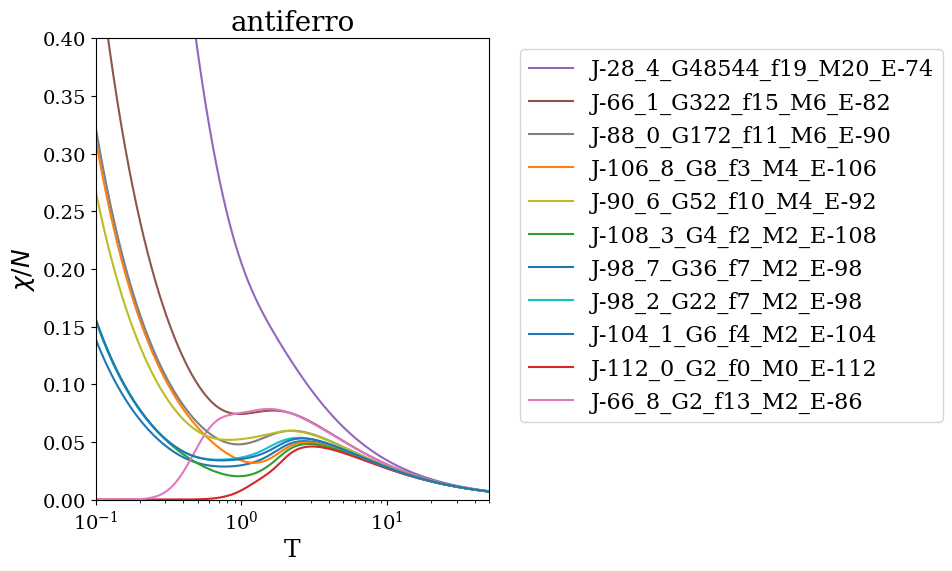

In [37]:
# --- Загрузка данных ---
folder = "data/term/antiferro/"
folder_path = Path(folder)   # или "."

files = list(folder_path.glob("term_*.dat"))

if not files:
	raise FileNotFoundError("Нет файлов term_*.dat")

plt.figure(figsize=(10, 6))

# магнитная восприимчивость
# for i in range(1): # files:
for i in files:
	filename = str(i)
	print(filename)
	# filename = str(files[1])

	open(filename, "r")
	input_file = Path(filename)

	# --- имя без расширения ---
	# name_without_extension = input_file.stem[17:]
	name_without_extension = input_file.stem
	# name_without_extension = name_without_extension.strip('term_gem_glass64_').strip('_H0.0')
	name_without_extension = name_without_extension.replace('term_gem_glass64_', '').replace('_H0.0', '')
	# name_without_extension = name_without_extension.strip('_H0.0')
	# name_without_extension = name_without_extension

	# sep=r"\s+" означает "один или несколько пробелов/табов"
	df = pd.read_csv(input_file, sep=r"\s+", engine="python")

	x = df.iloc[:, 0]   # первый столбец — X (температура)
	y = df.iloc[:, 4]   # пятый столбец (восприимчивость)

	# --- Построение графиков ---

	# plt.plot(x, y, color="blue", label="G_gs, N_frustrations")
	# plt.plot(x, y, label="G_gs, N_frustrations")
	plt.plot(x, y, label=name_without_extension)


# Настройка графика
plt.xlabel("T")
#plt.ylabel(df.columns[4])
# plt.ylabel(r"1/$\chi$")
plt.ylabel(r"$\chi/N$")
# plt.title("(c)")
# plt.title(name_without_extension)
plt.title('antiferro')

# plt.legend(loc="best")
# Получаем текущие линии и их данные
lines = plt.gca().get_lines()
handles, labels = plt.gca().get_legend_handles_labels()

# Сортируем по первому значению Y
pairs = list(zip(handles, labels))
sorted_pairs = sorted(pairs, key=lambda pair: pair[0].get_ydata()[0], reverse=True)

handles_sorted, labels_sorted = zip(*sorted_pairs)

# Применяем отсортированную легенду
# plt.legend(handles_sorted, labels_sorted)
plt.legend(handles_sorted, labels_sorted, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xscale("log")
# plt.yscale("log")


# === ДИАПАЗОНЫ ===
plt.xlim(0.1, 50)     # X от 0 до 10
plt.ylim(0, 0.4)    # Y от -5 до 20

plt.tight_layout()

# Сохранение графика в файл
# plt.savefig(f"{folder_path}/Xi_{name_without_extension}.png", dpi=300, bbox_inches='tight')  # формат можно изменить: .png, .jpg, .pdf, .svg
plt.show()

plt.close()

data\term\antiferro\1\term_gem_glass64_J-28_4_H0.0_G48544_f19_M20_E-74.dat
data\term\antiferro\1\term_gem_glass64_J-66_1_H0.0_G322_f15_M6_E-82.dat


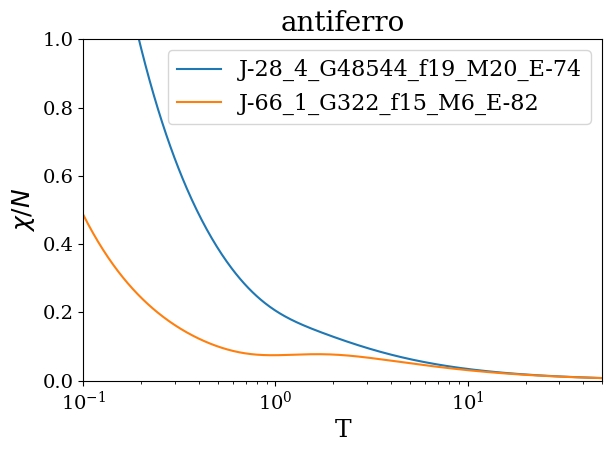

In [36]:
# --- Загрузка данных ---
folder = "data/term/antiferro/1/"
folder_path = Path(folder)   # или "."

files = list(folder_path.glob("term_*.dat"))

if not files:
	raise FileNotFoundError("Нет файлов term_*.dat")

# plt.figure(figsize=(10, 6))

# магнитная восприимчивость
# for i in range(1): # files:
for i in files:
	filename = str(i)
	print(filename)
	# filename = str(files[1])

	open(filename, "r")
	input_file = Path(filename)

	# --- имя без расширения ---
	# name_without_extension = input_file.stem[17:]
	name_without_extension = input_file.stem
	# name_without_extension = name_without_extension.strip('term_gem_glass64_').strip('_H0.0')
	name_without_extension = name_without_extension.replace('term_gem_glass64_', '').replace('_H0.0', '')
	# name_without_extension = name_without_extension.strip('_H0.0')
	# name_without_extension = name_without_extension

	# sep=r"\s+" означает "один или несколько пробелов/табов"
	df = pd.read_csv(input_file, sep=r"\s+", engine="python")

	x = df.iloc[:, 0]   # первый столбец — X (температура)
	y = df.iloc[:, 4]   # пятый столбец (восприимчивость)

	# --- Построение графиков ---

	# plt.plot(x, y, color="blue", label="G_gs, N_frustrations")
	# plt.plot(x, y, label="G_gs, N_frustrations")
	plt.plot(x, y, label=name_without_extension)


# Настройка графика
plt.xlabel("T")
#plt.ylabel(df.columns[4])
# plt.ylabel(r"1/$\chi$")
plt.ylabel(r"$\chi/N$")
# plt.title("(c)")
# plt.title(name_without_extension)
plt.title('antiferro')

plt.legend(loc="best")

plt.xscale("log")
# plt.yscale("log")


# === ДИАПАЗОНЫ ===
plt.xlim(0.1, 50)     # X от 0 до 10
plt.ylim(0, 1)    # Y от -5 до 20

plt.tight_layout()

# Сохранение графика в файл
# plt.savefig(f"{folder_path}/Xi_{name_without_extension}.png", dpi=300, bbox_inches='tight')  # формат можно изменить: .png, .jpg, .pdf, .svg
plt.show()

plt.close()

data\term\antiferro\2\term_gem_glass64_J-104_1_H0.0_G6_f4_M2_E-104.dat
data\term\antiferro\2\term_gem_glass64_J-106_8_H0.0_G8_f3_M4_E-106.dat
data\term\antiferro\2\term_gem_glass64_J-108_3_H0.0_G4_f2_M2_E-108.dat
data\term\antiferro\2\term_gem_glass64_J-112_0_H0.0_G2_f0_M0_E-112.dat
data\term\antiferro\2\term_gem_glass64_J-66_8_H0.0_G2_f13_M2_E-86.dat
data\term\antiferro\2\term_gem_glass64_J-88_0_H0.0_G172_f11_M6_E-90.dat
data\term\antiferro\2\term_gem_glass64_J-90_6_H0.0_G52_f10_M4_E-92.dat
data\term\antiferro\2\term_gem_glass64_J-98_2_H0.0_G22_f7_M2_E-98.dat
data\term\antiferro\2\term_gem_glass64_J-98_7_H0.0_G36_f7_M2_E-98.dat


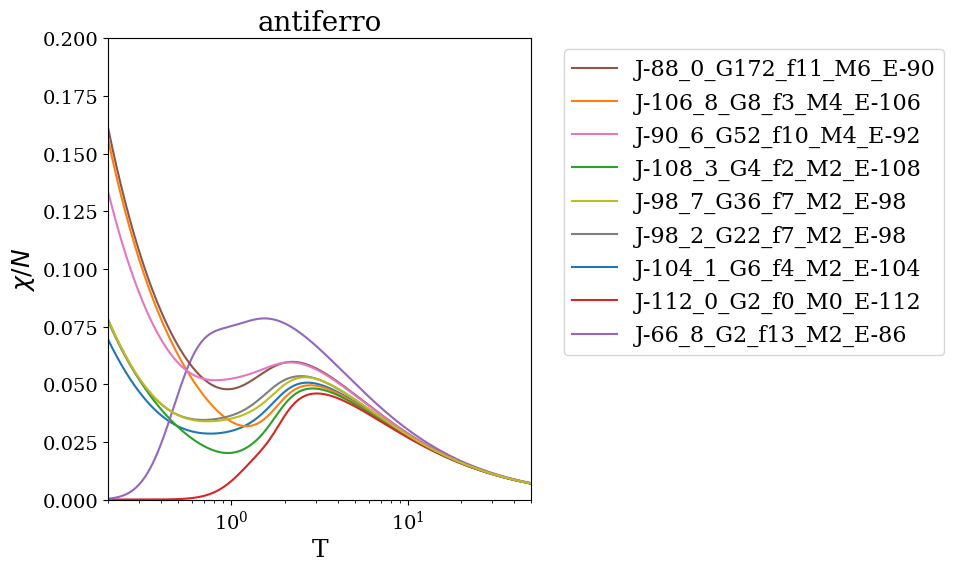

In [35]:
# --- Загрузка данных ---
folder = "data/term/antiferro/2/"
folder_path = Path(folder)   # или "."

files = list(folder_path.glob("term_*.dat"))

if not files:
	raise FileNotFoundError("Нет файлов term_*.dat")

plt.figure(figsize=(10, 6))

# магнитная восприимчивость
# for i in range(1): # files:
for i in files:
	filename = str(i)
	print(filename)
	# filename = str(files[1])

	open(filename, "r")
	input_file = Path(filename)

	# --- имя без расширения ---
	# name_without_extension = input_file.stem[17:]
	name_without_extension = input_file.stem
	# name_without_extension = name_without_extension.strip('term_gem_glass64_').strip('_H0.0')
	name_without_extension = name_without_extension.replace('term_gem_glass64_', '').replace('_H0.0', '')
	# name_without_extension = name_without_extension.strip('_H0.0')
	# name_without_extension = name_without_extension

	# sep=r"\s+" означает "один или несколько пробелов/табов"
	df = pd.read_csv(input_file, sep=r"\s+", engine="python")

	x = df.iloc[:, 0]   # первый столбец — X (температура)
	y = df.iloc[:, 4]   # пятый столбец (восприимчивость)

	# --- Построение графиков ---

	# plt.plot(x, y, color="blue", label="G_gs, N_frustrations")
	# plt.plot(x, y, label="G_gs, N_frustrations")
	plt.plot(x, y, label=name_without_extension)


# Настройка графика
plt.xlabel("T")
#plt.ylabel(df.columns[4])
# plt.ylabel(r"1/$\chi$")
plt.ylabel(r"$\chi/N$")
# plt.title("(c)")
# plt.title(name_without_extension)
plt.title('antiferro')

# plt.legend(loc="best")
# Получаем текущие линии и их данные
lines = plt.gca().get_lines()
handles, labels = plt.gca().get_legend_handles_labels()

# Сортируем по первому значению Y
pairs = list(zip(handles, labels))
sorted_pairs = sorted(pairs, key=lambda pair: pair[0].get_ydata()[0], reverse=True)

handles_sorted, labels_sorted = zip(*sorted_pairs)

# Применяем отсортированную легенду
# plt.legend(handles_sorted, labels_sorted)
plt.legend(handles_sorted, labels_sorted, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xscale("log")
# plt.yscale("log")


# === ДИАПАЗОНЫ ===
plt.xlim(0.2, 50)     # X от 0 до 10
plt.ylim(0, 0.2)    # Y от -5 до 20

plt.tight_layout()

# Сохранение графика в файл
# plt.savefig(f"{folder_path}/Xi_{name_without_extension}.png", dpi=300, bbox_inches='tight')  # формат можно изменить: .png, .jpg, .pdf, .svg
plt.show()

plt.close()

data\term\glass\term_gem_glass64_J0_0_H0.0_G190_f15_M12_E-82.dat
data\term\glass\term_gem_glass64_J0_1_H0.0_G12032_f18_M20_E-76.dat
data\term\glass\term_gem_glass64_J0_2_H0.0_G210_f17_M14_E-78.dat
data\term\glass\term_gem_glass64_J0_3_H0.0_G1344_f15_M20_E-82.dat
data\term\glass\term_gem_glass64_J0_4_H0.0_G660_f17_M18_E-78.dat
data\term\glass\term_gem_glass64_J0_5_H0.0_G1192_f18_M14_E-76.dat
data\term\glass\term_gem_glass64_J0_6_H0.0_G64_f15_M18_E-82.dat
data\term\glass\term_gem_glass64_J0_7_H0.0_G254_f15_M14_E-82.dat
data\term\glass\term_gem_glass64_J0_8_H0.0_G1674_f17_M18_E-78.dat
data\term\glass\term_gem_glass64_J0_9_H0.0_G746_f15_M14_E-82.dat
data\term\glass\term_gem_glass64_new2_J0_H0.0_G3211264_f25_M26_E-62.dat


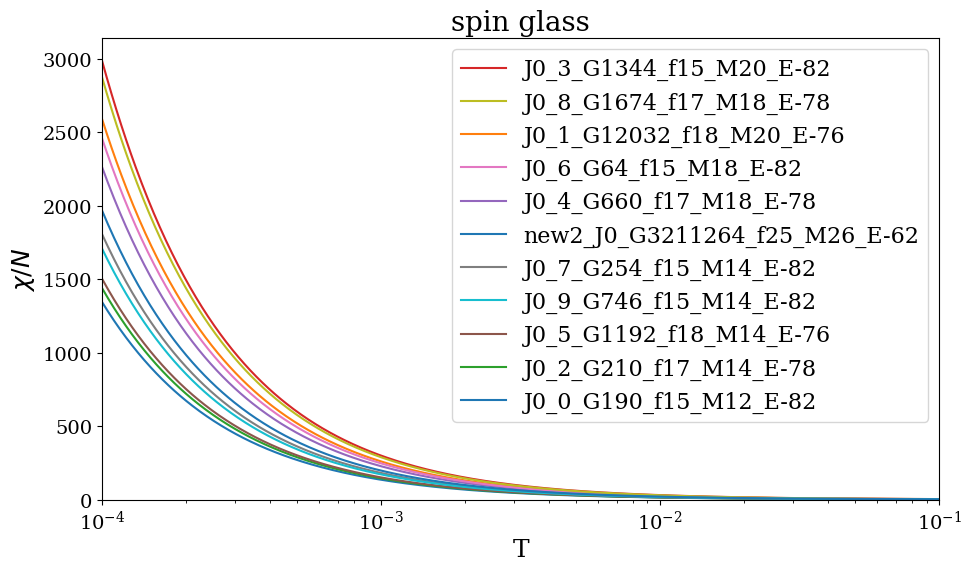

In [23]:
# --- Загрузка данных ---
folder = "data/term/glass/"
folder_path = Path(folder)   # или "."

files = list(folder_path.glob("term_*.dat"))

if not files:
	raise FileNotFoundError("Нет файлов term_*.dat")

plt.figure(figsize=(10, 6))

# магнитная восприимчивость
# for i in range(1): # files:
for i in files:
	filename = str(i)
	print(filename)
	# filename = str(files[1])

	open(filename, "r")
	input_file = Path(filename)

	# --- имя без расширения ---
	# name_without_extension = input_file.stem[17:]
	name_without_extension = input_file.stem
	# name_without_extension = name_without_extension.strip('term_gem_glass64_').strip('_H0.0')
	name_without_extension = name_without_extension.replace('term_gem_glass64_', '').replace('_H0.0', '')
	# name_without_extension = name_without_extension.strip('_H0.0')
	# name_without_extension = name_without_extension

	# sep=r"\s+" означает "один или несколько пробелов/табов"
	df = pd.read_csv(input_file, sep=r"\s+", engine="python")

	x = df.iloc[:, 0]   # первый столбец — X (температура)
	y = df.iloc[:, 4]   # пятый столбец (восприимчивость)

	# --- Построение графиков ---

	# plt.plot(x, y, color="blue", label="G_gs, N_frustrations")
	# plt.plot(x, y, label="G_gs, N_frustrations")
	plt.plot(x, y, label=name_without_extension)


# Настройка графика
plt.xlabel("T")
#plt.ylabel(df.columns[4])
# plt.ylabel(r"1/$\chi$")
plt.ylabel(r"$\chi/N$")
# plt.title("(c)")
# plt.title(name_without_extension)
plt.title('spin glass')

# plt.legend(loc="best")

# Получаем текущие линии и их данные
lines = plt.gca().get_lines()
handles, labels = plt.gca().get_legend_handles_labels()

# Сортируем по первому значению Y
pairs = list(zip(handles, labels))
sorted_pairs = sorted(pairs, key=lambda pair: pair[0].get_ydata()[0], reverse=True)

handles_sorted, labels_sorted = zip(*sorted_pairs)

# Применяем отсортированную легенду
plt.legend(handles_sorted, labels_sorted)

plt.xscale("log")
# plt.yscale("log")


# === ДИАПАЗОНЫ ===
plt.xlim(0.0001, 0.1)     # X от 0 до 10
plt.ylim(0, )    # Y от -5 до 20

plt.tight_layout()

# Сохранение графика в файл
# plt.savefig(f"{folder_path}/Xi_{name_without_extension}.png", dpi=300, bbox_inches='tight')  # формат можно изменить: .png, .jpg, .pdf, .svg
plt.show()

plt.close()